In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [35]:
df = pd.read_csv(r'..\dataset\hotel_bookings.csv', keep_default_na=False)
df.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
0,100000,424,Customer_424,Group,2023-07-03,Manali,Platinum,38,Crimson Courtyard,Manali,...,4,OTA,5808.46,0.00,NONE,46467.68,Debit Card,Cancelled,,
1,100001,239,Customer_239,Individual,2022-07-18,Jaipur,None,32,Saffron Palace,Pune,...,4,Corporate Portal,4021.62,0.00,,16086.48,Net Banking,Cancelled,,
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,...,3,Corporate Portal,17663.11,15373.35,SAVE10,90605.31,Net Banking,Completed,,
3,100003,722,Customer_722,Individual,2022-11-07,Udaipur,None,43,Indigo Lodge,Bangalore,...,3,OTA,5885.85,0.00,NONE,17657.55,Credit Card,No-Show,,
4,100004,306,Customer_306,Corporate,2022-02-02,Udaipur,Silver,29,Cedar Lodge,Kochi,...,7,Direct Website,6199.44,5924.82,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21


In [36]:
df.columns

Index(['booking_id', 'customer_id', 'customer_name', 'customer_segment',
       'customer_signup_date', 'customer_home_city', 'customer_loyalty_tier',
       'property_id', 'property_name', 'property_city', 'property_star_rating',
       'property_type', 'property_total_rooms', 'booking_date', 'checkin_date',
       'checkout_date', 'room_type', 'num_rooms', 'nights', 'booking_channel',
       'adr', 'discount_amount', 'coupon_code', 'total_amount',
       'payment_method', 'booking_status', 'review_rating', 'review_date'],
      dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   booking_id             12000 non-null  int64  
 1   customer_id            12000 non-null  int64  
 2   customer_name          12000 non-null  object 
 3   customer_segment       12000 non-null  object 
 4   customer_signup_date   12000 non-null  object 
 5   customer_home_city     12000 non-null  object 
 6   customer_loyalty_tier  12000 non-null  object 
 7   property_id            12000 non-null  int64  
 8   property_name          12000 non-null  object 
 9   property_city          12000 non-null  object 
 10  property_star_rating   12000 non-null  int64  
 11  property_type          12000 non-null  object 
 12  property_total_rooms   12000 non-null  int64  
 13  booking_date           12000 non-null  object 
 14  checkin_date           12000 non-null  object 
 15  ch

In [38]:
df.describe()

,booking_id,customer_id,property_id,property_star_rating,property_total_rooms,num_rooms,nights,adr,discount_amount,total_amount
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,105999.50000,399.371250,27.936833,3.633917,87.582500,1.442833,2.850250,8033.759119,1722.596401,31313.479270
std,3464.24595,230.356836,15.991205,1.084588,38.491612,0.894035,1.523708,6882.096052,5472.858618,44217.972507
min,100000.00000,1.000000,1.000000,2.000000,30.000000,0.000000,1.000000,1619.950000,0.000000,0.000000
25%,102999.75000,201.000000,14.000000,3.000000,60.000000,1.000000,2.000000,3677.615000,0.000000,8926.725000
50%,105999.50000,400.000000,28.000000,4.000000,80.000000,1.000000,3.000000,5724.160000,0.000000,17274.720000
75%,108999.25000,596.000000,42.000000,5.000000,120.000000,2.000000,4.000000,9765.242500,1309.595000,35677.547500
max,111999.00000,800.000000,60.000000,5.000000,200.000000,5.000000,7.000000,63851.460000,174504.110000,925274.700000


# Section 1

# C1

In [39]:
count = len(df[df['num_rooms']==0])
print(count)

60


# C2

In [40]:
invalid_bookings = df[df['booking_date'] < df['customer_signup_date']]

print("Count:", len(invalid_bookings))

Count: 163


# C3


In [41]:
missing_reviews = (df["review_rating"] == "").sum()
missing_reviews_percentage = (missing_reviews / len(df)) * 100
print(f"Missing review ratings: {missing_reviews} ({missing_reviews_percentage:.2f}%)")

Missing review ratings: 6854 (57.12%)


In [42]:
df["review_missing"] = df["review_rating"] == ""

In [43]:
summary = df.groupby("booking_status").agg(
    total_bookings=("review_missing", "count"),
    missing_reviews=("review_missing", "sum")
)

In [44]:
summary["missing_percentage"] = (
    summary["missing_reviews"] /
    summary["total_bookings"] * 100
)
print (summary)

                total_bookings  missing_reviews  missing_percentage
booking_status                                                     
Cancelled                 2302             2252           97.827976
Completed                 9333             4237           45.398050
No-Show                    365              365          100.000000


# Section 2

# C1 – Define VIP Three Ways

In [45]:
completed = df[df["booking_status"] == "Completed"].copy()

completed["booking_date"] = pd.to_datetime(completed["booking_date"])
completed["customer_signup_date"] = pd.to_datetime(
    completed["customer_signup_date"]
)

# VIP Definition 1: Spend

In [46]:
spend_rank = (
    completed.groupby("customer_id")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

top_n = int(np.ceil(len(spend_rank) * 0.10))

vip_spend = set(spend_rank.head(top_n).index)

# VIP Definition 2: Volume

In [47]:
volume_rank = (
    completed.groupby("customer_id")
    .size()
    .sort_values(ascending=False)
)

vip_volume = set(volume_rank.head(top_n).index)

# VIP Definition 3: Booking Count

In [ ]:
booking_rank = (
    completed.groupby("customer_id").size().sort_values(ascending=False))

vip_booking = set(booking_rank.head(top_n).index)

# VIP Definition 4: LTV Rate

In [48]:
ltv = completed.groupby("customer_id").agg(
    total_spend=("total_amount", "sum"),
    signup_date=("customer_signup_date", "first")
)
analysis_date = completed["booking_date"].max()

In [49]:
ltv["months_since_signup"] = ((analysis_date - ltv["signup_date"]).dt.days / 30.44)

In [50]:
ltv["months_since_signup"] = (ltv["months_since_signup"].clip(lower=1))

In [51]:
ltv["ltv_rate"] = (ltv["total_spend"] /ltv["months_since_signup"])

In [52]:
vip_ltv = set(ltv.sort_values("ltv_rate",ascending=False).head(top_n).index)

In [54]:
membership = Counter()

for c in vip_spend:
    membership[c] += 1

for c in vip_volume:
    membership[c] += 1

for c in vip_ltv:
    membership[c] += 1

only_one = sum(v == 1 for v in membership.values())
exactly_two = sum(v == 2 for v in membership.values())
all_three = sum(v == 3 for v in membership.values())

print("Only One:", only_one)
print("Exactly Two:", exactly_two)
print("All Three:", all_three)

Only One: 102
Exactly Two: 57
All Three: 8


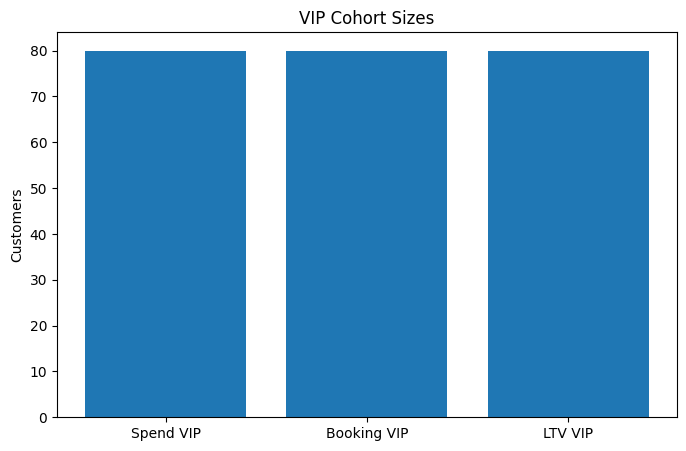

In [58]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Spend VIP", "Booking VIP", "LTV VIP"],
    [len(vip_spend), len(vip_booking), len(vip_ltv)]
)

plt.title("VIP Cohort Sizes")
plt.ylabel("Customers")

plt.show()

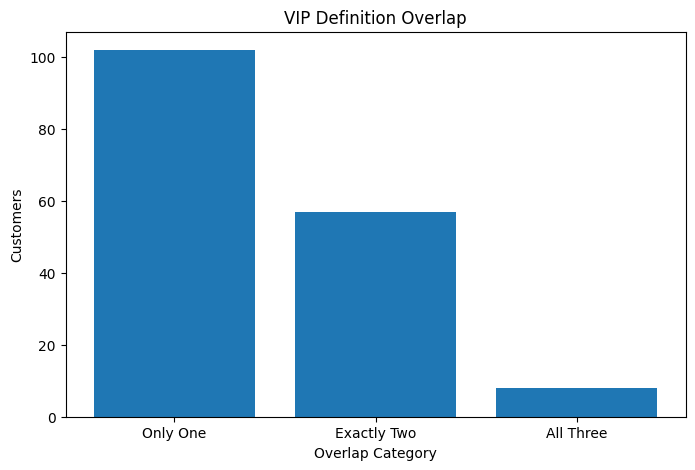

In [55]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Only One", "Exactly Two", "All Three"],
    [only_one, exactly_two, all_three]
)

plt.title("VIP Definition Overlap")
plt.ylabel("Customers")
plt.xlabel("Overlap Category")

plt.show()

# C2 – VIP Risk Profile

**Spend-Based VIP**

In [59]:
vip_customers = vip_spend

df["is_vip"] = (
    df["customer_id"].isin(vip_customers))

**Revenue Share**

In [60]:
completed["is_vip"] = (completed["customer_id"].isin(vip_customers))

vip_revenue = completed.loc[completed["is_vip"],"total_amount"].sum()

total_revenue = completed["total_amount"].sum()

vip_revenue_share = (vip_revenue /total_revenue) * 100

print("VIP Revenue Share:", vip_revenue_share)

VIP Revenue Share: 26.835276325046575


**Cancellation Rate**

In [62]:
cancel_rate = (
    df.groupby("is_vip")["booking_status"].apply(lambda x: (x == "Cancelled").mean()*100))

print(cancel_rate)

is_vip
False    19.450178
True     17.064083
Name: booking_status, dtype: float64


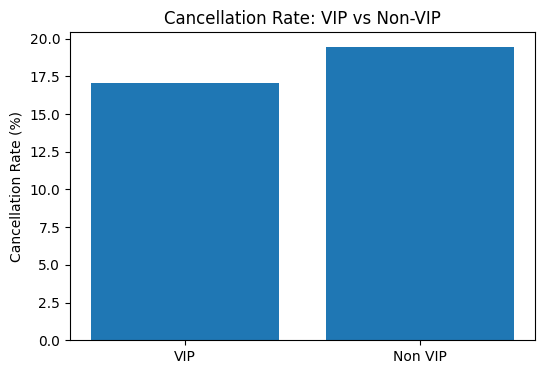

In [82]:
plt.figure(figsize=(6,4))

plt.bar(
    ["VIP","Non VIP"],
    [17.06,19.45]
)

plt.title("Cancellation Rate: VIP vs Non-VIP")
plt.ylabel("Cancellation Rate (%)")

plt.show()

**Discount Intensity**

In [63]:
discount_intensity = (
    df.groupby("is_vip")["discount_amount"].mean())

print(discount_intensity)

is_vip
False    1439.985513
True     3967.057534
Name: discount_amount, dtype: float64


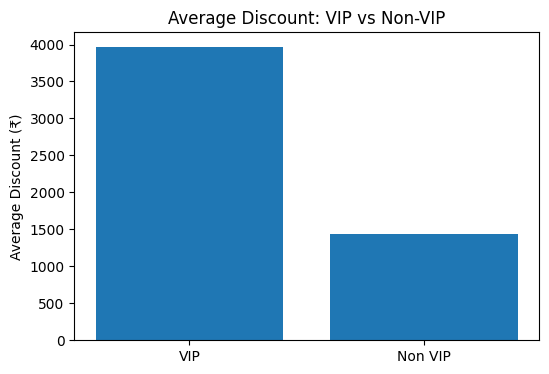

In [83]:
plt.figure(figsize=(6,4))

plt.bar(
    ["VIP","Non VIP"],
    [3967.06,1439.99]
)

plt.title("Average Discount: VIP vs Non-VIP")
plt.ylabel("Average Discount (₹)")

plt.show()

In [70]:
comparison = pd.DataFrame({
    "Metric": [
        "Cancellation Rate",
        "Discount Intensity"
    ],
    "VIP": [
        cancel_rate[True],
        discount_intensity[True]
    ],
    "Non VIP": [
        cancel_rate[False],
        discount_intensity[False]
    ]
})

x = np.arange(len(comparison))
width = 0.5

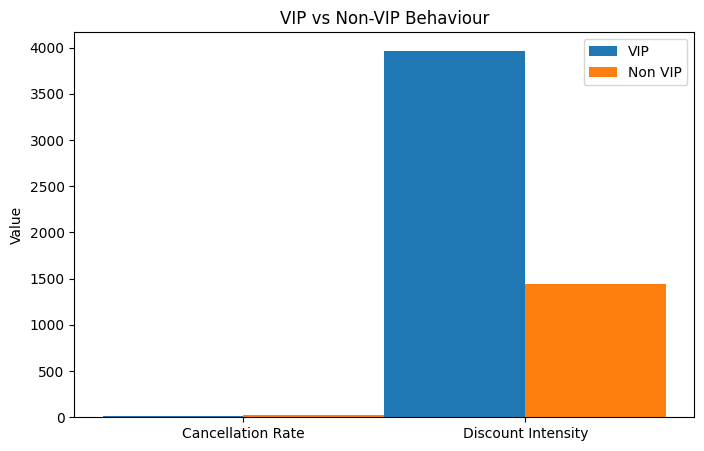

In [71]:
plt.figure(figsize=(8,5))

plt.bar(x - width/2, comparison["VIP"], width, label="VIP")

plt.bar(
    x + width/2,
    comparison["Non VIP"], width, label="Non VIP")

plt.xticks(x, comparison["Metric"])
plt.ylabel("Value")
plt.title("VIP vs Non-VIP Behaviour")
plt.legend()

plt.show()

# C3 – Acquisition Math

In [72]:
budget = 5000000 
cac = 3000

new_customers = budget / cac

print("New Customers:", round(new_customers))

New Customers: 1667


**Average Customer Lifetime Spend**

In [75]:
customer_lifetime_spend = (
    completed.groupby("customer_id")["total_amount"].sum()
)

avg_lifetime_spend = (customer_lifetime_spend.mean())
print(avg_lifetime_spend)

368574.7395125


**Gross Lifetime Revenue**

In [78]:
gross_lifetime_revenue = (new_customers *avg_lifetime_spend)
print("Gross Lifetime Revenue:",gross_lifetime_revenue)

Gross Lifetime Revenue: 614291232.5208334


**Year-1 Revenue**

In [79]:
year1_revenue = (gross_lifetime_revenue *0.20)
print("Year-1 Revenue:",year1_revenue)

Year-1 Revenue: 122858246.50416668


# C4 – Retention Math

In [80]:
retention_cost = 500
customers_retained = (budget /retention_cost)
print("Customers Retained:",customers_retained)

Customers Retained: 10000.0


**Break-Even Computation**

In [81]:
break_even_ltv = ( retention_cost /0.20)
print("Break-Even Lifetime Spend:",break_even_ltv)

Break-Even Lifetime Spend: 2500.0


**Acquisition vs Retention Reach**

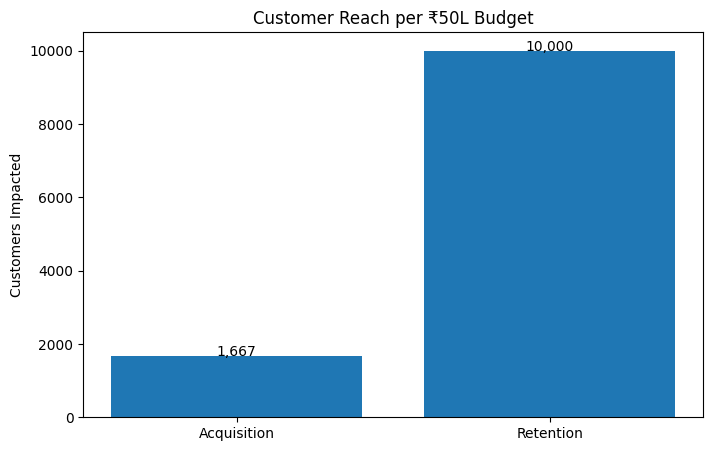

In [84]:
plt.figure(figsize=(8,5))

strategies = ["Acquisition", "Retention"]
customers = [1667, 10000]

bars = plt.bar(strategies, customers)

plt.title("Customer Reach per ₹50L Budget")
plt.ylabel("Customers Impacted")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha='center'
    )

plt.show()

**Revenue Economics**

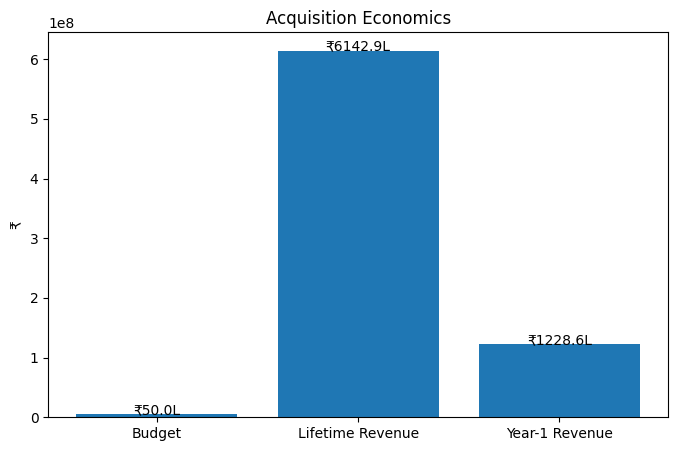

In [88]:
plt.figure(figsize=(8,5))

metrics = ["Budget", "Lifetime Revenue", "Year-1 Revenue"]

values = [5000000, 614291232.52, 122858246.50]

bars = plt.bar(metrics, values)

plt.title("Acquisition Economics")
plt.ylabel("₹")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"₹{bar.get_height()/100000:.1f}L",
        ha='center'
    )

plt.show()

**Break-Even Analysis**

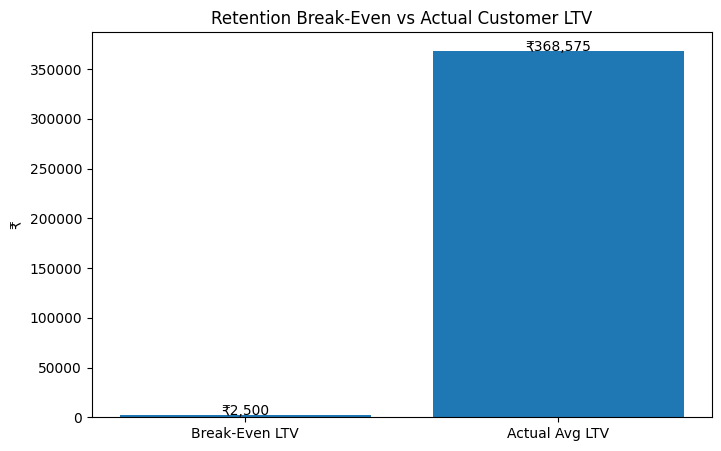

In [87]:
plt.figure(figsize=(8,5))

labels = ["Break-Even LTV","Actual Avg LTV"]

values = [2500,368574.74]

bars = plt.bar(labels, values)

plt.title("Retention Break-Even vs Actual Customer LTV")
plt.ylabel("₹")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"₹{bar.get_height():,.0f}",
        ha='center'
    )

plt.show()

In [90]:
df.columns

Index(['booking_id', 'customer_id', 'customer_name', 'customer_segment',
       'customer_signup_date', 'customer_home_city', 'customer_loyalty_tier',
       'property_id', 'property_name', 'property_city', 'property_star_rating',
       'property_type', 'property_total_rooms', 'booking_date', 'checkin_date',
       'checkout_date', 'room_type', 'num_rooms', 'nights', 'booking_channel',
       'adr', 'discount_amount', 'coupon_code', 'total_amount',
       'payment_method', 'booking_status', 'review_rating', 'review_date',
       'review_missing', 'is_vip'],
      dtype='object')